## Autoencoder Implementation using MNIST
### 1. Introduction

#### An Autoencoder is an unsupervised neural network used to learn efficient data representations. It consists of two parts:

- Encoder → Compresses input into a latent representation
- Decoder → Reconstructs the original input from the compressed data

#### Here, we build a basic autoencoder using the MNIST handwritten digits dataset.

### 2. Model Design
#### 2.1 Import Required Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

#### 2.2 Load and Preprocess Dataset

In [5]:
# Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for model input
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#### 2.3 Build the Autoencoder
- Encoder

In [6]:
input_img = Input(shape=(28, 28))

# Flatten input
x = Flatten()(input_img)

# Encoding layers
encoded = Dense(64, activation='relu')(x)
encoded = Dense(32, activation='relu')(encoded)

- Decoder

In [7]:
# Decoding layers
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(28*28, activation='sigmoid')(decoded)

# Reshape back to image
decoded = Reshape((28, 28))(decoded)

- Autoencoder Model

In [8]:
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

#### 3. Model Training

In [9]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.2563 - val_loss: 0.1750
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1564 - val_loss: 0.1387
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1313 - val_loss: 0.1234
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1214 - val_loss: 0.1166
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1157 - val_loss: 0.1114
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1111 - val_loss: 0.1076
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1080 - val_loss: 0.1054
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1064 - val_loss: 0.1041
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1049 - val_loss: 0.1028
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1035 - val_loss: 0.1016
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1020 - val_loss: 0.0998
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### 4. Model Evaluation and Visualization
#### 4.1 Model Summary

In [10]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │          50,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 316,178 (1.21 MB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 210,786 (823.39 KB)

#### 4.2 Training vs Validation Loss Curve

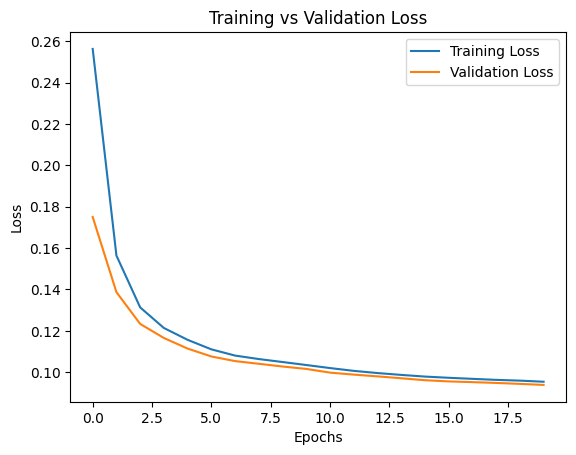

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#### 4.3 Reconstruction Results (Original vs Reconstructed Images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


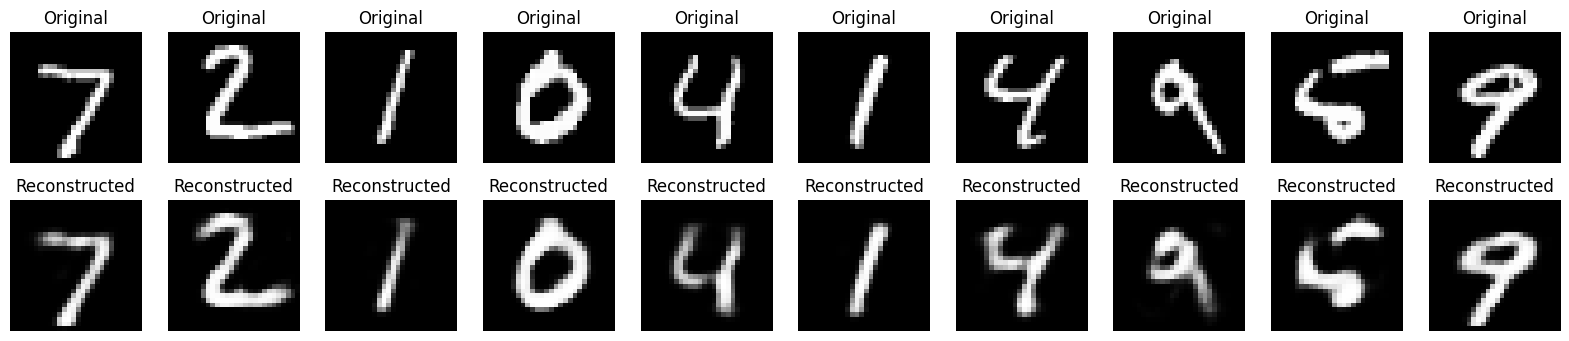

In [12]:
# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Display comparison
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

#### 5. Results and Explanation

- The autoencoder successfully learned to compress and reconstruct handwritten digit images from the MNIST dataset. During training, both the training loss and validation loss decreased steadily, indicating that the model was effectively learning meaningful representations without significant overfitting.The reconstructed images closely resemble the original digits, although some fine details appear slightly blurred. This is expected because the encoder compresses the image into a lower-dimensional latent space, which results in some information loss. Overall, the model demonstrates the ability of autoencoders to perform dimensionality reduction and image reconstruction effectively.